# 07 - Production Readiness and Monitoring (10/10 Gate)

This notebook is the final production gate for the churn/reorder model. It unifies evidence from **03 training**, **04 causal inference**, **05 cohort/time-series diagnostics**, and **06 deployment scoring**.

## What this notebook now does

- Runs a unified preflight with **artifact**, **model**, **data**, **causal**, and **monitoring** checks.
- Implements a **study-guide-aligned audit** for chapters 3-8 (time series, cohorts, text quality, anomaly handling, experiments, dataset governance).
- Produces an executive decision: **`ship` / `pilot` / `block`** with reason codes and remediation actions.
- Persists machine-readable and human-readable outputs for release governance.

In [1]:
# Cell 0: Setup and artifact paths
from __future__ import annotations

import importlib.util
import json
from datetime import UTC, datetime
from pathlib import Path
import sys
from typing import Any

import numpy as np
import pandas as pd
from IPython.display import display

HAS_MPL = importlib.util.find_spec("matplotlib") is not None
if HAS_MPL:
    import matplotlib.pyplot as plt

required_libs = ["numpy", "pandas"]
missing_libs = [lib for lib in required_libs if importlib.util.find_spec(lib) is None]
if missing_libs:
    raise RuntimeError(
        "Missing required packages for Notebook 07: "
        + ", ".join(missing_libs)
        + "; install with: apps/backend/.venv/bin/python -m pip install -r ml/requirements.txt"
    )

ROOT = Path.cwd()
for pth in [ROOT, *ROOT.parents]:
    if (pth / "ml" / "pipelines" / "production_preflight.py").exists():
        ROOT = pth
        break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PATHS = {
    "METRICS_PATH": ROOT / "ml" / "models" / "churn_reorder_metrics.json",
    "BASELINE_PATH": ROOT / "ml" / "models" / "churn_drift_baseline.json",
    "SCORING_PATH": ROOT / "ml" / "data" / "churn_scoring_latest.csv",
    "DATASET_PATH": ROOT / "ml" / "data" / "churn_training_dataset.csv",
    "FEATURE_DATASET_PATH": ROOT / "ml" / "data" / "churn_training_features.csv",
    "DEPLOY_SUMMARY_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "deployment_scoring_summary.json",
    "PROD_MONITOR_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "production_monitoring.json",
    "CAUSAL_DECISION_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "causal_release_decision.json",
    "AB_RESULTS_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "ab_test" / "ab_test_results.json",
    "DID_RESULTS_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "did" / "did_results.json",
    "COHORT_SUMMARY_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "cohort_time_series" / "cohort_time_series_summary.json",
    "DAILY_TIMESERIES_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "cohort_time_series" / "daily_timeseries_metrics.csv",
    "COHORT_RET_MATRIX_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "cohort_time_series" / "cohort_retention_matrix.csv",
    "COHORT_FIXED_WINDOW_PATH": ROOT / "ml" / "data" / "reports" / "causal" / "cohort_time_series" / "cohort_fixed_window_metrics.csv",
    "THRESHOLD_CURVE_PATH": ROOT / "ml" / "models" / "churn_threshold_curve.csv",
    "FEATURE_IMPORTANCE_PATH": ROOT / "ml" / "models" / "churn_feature_importance.csv",
    "REVIEWS_CLEAN_PATH": ROOT / "ml" / "data" / "clean" / "reviews_clean.parquet",
    "RELEASE_JSON_PATH": ROOT / "ml" / "models" / "release_preflight_report.json",
    "RELEASE_MD_PATH": ROOT / "ml" / "models" / "release_preflight_report.md",
    "MONITOR_JSON_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "production_monitoring.json",
    "MONITOR_MD_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "production_monitoring.md",
    "STUDY_AUDIT_JSON_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "study_guide_implementation_audit.json",
    "STUDY_AUDIT_MD_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "study_guide_implementation_audit.md",
    "CHECKS_CSV_PATH": ROOT / "ml" / "data" / "reports" / "churn" / "production_readiness_checks.csv",
}

path_rows = [
    {
        "artifact": name,
        "exists": path.exists(),
        "path": str(path),
    }
    for name, path in PATHS.items()
]
path_df = pd.DataFrame(path_rows).sort_values(["exists", "artifact"], ascending=[True, True]).reset_index(drop=True)

print("ROOT:", ROOT)
print("matplotlib_available:", HAS_MPL)
display(path_df)

ROOT: /Users/deliorincon/Desktop/Sliceiq
matplotlib_available: True


,artifact,exists,path
0,REVIEWS_CLEAN_PATH,False,/Users/deliorincon/Desktop/Sliceiq/ml/data/cle...
1,AB_RESULTS_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
2,BASELINE_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/models/c...
3,CAUSAL_DECISION_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
4,CHECKS_CSV_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
5,COHORT_FIXED_WINDOW_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
6,COHORT_RET_MATRIX_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
7,COHORT_SUMMARY_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
8,DAILY_TIMESERIES_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...
9,DATASET_PATH,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/chu...


In [2]:
# Cell 1: Load outputs from notebooks 03-06 + supporting datasets
def _read_json(path: Path, default: Any):
    if not path.exists():
        return default
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return default


def _read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.DataFrame()


def _safe_float(value: Any) -> float:
    try:
        out = float(value)
        if np.isfinite(out):
            return out
        return float("nan")
    except Exception:
        return float("nan")


metrics = _read_json(PATHS["METRICS_PATH"], {})
baseline = _read_json(PATHS["BASELINE_PATH"], {})
deploy_summary = _read_json(PATHS["DEPLOY_SUMMARY_PATH"], {})
prior_monitor = _read_json(PATHS["PROD_MONITOR_PATH"], {})
causal_decision = _read_json(PATHS["CAUSAL_DECISION_PATH"], {})
ab_results = _read_json(PATHS["AB_RESULTS_PATH"], {})
did_results = _read_json(PATHS["DID_RESULTS_PATH"], {})
cohort_summary = _read_json(PATHS["COHORT_SUMMARY_PATH"], {})

scored = _read_csv(PATHS["SCORING_PATH"])
dataset = _read_csv(PATHS["DATASET_PATH"])
feature_dataset = _read_csv(PATHS["FEATURE_DATASET_PATH"])
daily_timeseries = _read_csv(PATHS["DAILY_TIMESERIES_PATH"])
cohort_retention = _read_csv(PATHS["COHORT_RET_MATRIX_PATH"])
cohort_fixed_window = _read_csv(PATHS["COHORT_FIXED_WINDOW_PATH"])
threshold_curve = _read_csv(PATHS["THRESHOLD_CURVE_PATH"])
feature_importance = _read_csv(PATHS["FEATURE_IMPORTANCE_PATH"])

context_rows = [
    {
        "source_notebook": "03_training_and_evaluation",
        "signal": "test_roc_auc",
        "value": _safe_float(metrics.get("test_metrics", {}).get("roc_auc")),
    },
    {
        "source_notebook": "03_training_and_evaluation",
        "signal": "test_pr_auc",
        "value": _safe_float(metrics.get("test_metrics", {}).get("pr_auc")),
    },
    {
        "source_notebook": "03_training_and_evaluation",
        "signal": "threshold",
        "value": _safe_float(metrics.get("threshold")),
    },
    {
        "source_notebook": "04_causal_inference_ab_did",
        "signal": "final_decision",
        "value": causal_decision.get("final_decision", "unknown"),
    },
    {
        "source_notebook": "04_causal_inference_ab_did",
        "signal": "did_primary_p",
        "value": causal_decision.get("checks", {}).get("primary_did_p"),
    },
    {
        "source_notebook": "05_cohort_time_series",
        "signal": "daily_anomalies",
        "value": cohort_summary.get("daily_anomalies"),
    },
    {
        "source_notebook": "05_cohort_time_series",
        "signal": "cohorts",
        "value": cohort_summary.get("cohorts"),
    },
    {
        "source_notebook": "06_deployment_scoring",
        "signal": "scored_users",
        "value": deploy_summary.get("scored_users", len(scored)),
    },
    {
        "source_notebook": "06_deployment_scoring",
        "signal": "psi",
        "value": deploy_summary.get("monitor", {}).get("psi", prior_monitor.get("psi")),
    },
    {
        "source_notebook": "06_deployment_scoring",
        "signal": "high_risk_share",
        "value": deploy_summary.get("risk_mix", {}).get("high"),
    },
]

context_df = pd.DataFrame(context_rows)
display(context_df)

print(
    "Loaded rows:",
    {
        "scored": len(scored),
        "training_dataset": len(dataset),
        "feature_dataset": len(feature_dataset),
        "daily_timeseries": len(daily_timeseries),
        "cohort_retention_rows": len(cohort_retention),
        "threshold_curve_rows": len(threshold_curve),
    },
)

,source_notebook,signal,value
0,03_training_and_evaluation,test_roc_auc,0.998048
1,03_training_and_evaluation,test_pr_auc,0.997594
2,03_training_and_evaluation,threshold,0.312471
3,04_causal_inference_ab_did,final_decision,ship
4,04_causal_inference_ab_did,did_primary_p,0.0
5,05_cohort_time_series,daily_anomalies,6
6,05_cohort_time_series,cohorts,7
7,06_deployment_scoring,scored_users,200
8,06_deployment_scoring,psi,0.433781
9,06_deployment_scoring,high_risk_share,0.695


Loaded rows: {'scored': 200, 'training_dataset': 862, 'feature_dataset': 862, 'daily_timeseries': 172, 'cohort_retention_rows': 7, 'threshold_curve_rows': 161}


## Unified Preflight + Study Guide Audit

The checks below blend production criteria with chapter-based implementation checks:

- `ch3`: time series windows, scaffold continuity, seasonality
- `ch4`: cohort denominator integrity and fixed-window fairness
- `ch5`: text signal readiness / normalization checks
- `ch6`: anomaly features + outlier impact diagnostics
- `ch7`: experiment validity (SRM, readiness, DiD guardrails)
- `ch8`: governance artifacts, dimensionality reduction, privacy hygiene

In [3]:
# Cell 2: Build a 10/10 production-readiness check table
checks: list[dict[str, Any]] = []


def _status(ok: bool, *, warn: bool = False) -> str:
    if ok:
        return "pass"
    return "warn" if warn else "fail"


def _status_max(value: float, pass_max: float, warn_max: float) -> str:
    if pd.isna(value):
        return "warn"
    if value <= pass_max:
        return "pass"
    if value <= warn_max:
        return "warn"
    return "fail"


def _add_check(
    *,
    domain: str,
    check: str,
    status: str,
    value: Any,
    threshold: Any,
    evidence: str,
    why_it_matters: str,
    chapter: str | None = None,
) -> None:
    checks.append(
        {
            "domain": domain,
            "chapter": chapter,
            "check": check,
            "status": status,
            "value": value,
            "threshold": threshold,
            "evidence": evidence,
            "why_it_matters": why_it_matters,
        }
    )


# Existence gates
required_artifacts = [
    "METRICS_PATH",
    "BASELINE_PATH",
    "SCORING_PATH",
    "DATASET_PATH",
    "FEATURE_DATASET_PATH",
    "DEPLOY_SUMMARY_PATH",
    "CAUSAL_DECISION_PATH",
    "COHORT_SUMMARY_PATH",
]
for key in required_artifacts:
    p = PATHS[key]
    _add_check(
        domain="artifacts",
        chapter=None,
        check=f"{key.lower()}_exists",
        status=_status(p.exists()),
        value=p.exists(),
        threshold=True,
        evidence=str(p),
        why_it_matters="Core release evidence must be materialized before gating.",
    )

# Notebook 03 model quality checks
roc_auc = _safe_float(metrics.get("test_metrics", {}).get("roc_auc"))
pr_auc = _safe_float(metrics.get("test_metrics", {}).get("pr_auc"))
brier = _safe_float(metrics.get("test_metrics", {}).get("brier"))
threshold = _safe_float(metrics.get("threshold"))
selected_features = metrics.get("selected_features", []) if isinstance(metrics, dict) else []
selected_features = selected_features if isinstance(selected_features, list) else []

_add_check(
    domain="model_quality",
    chapter=None,
    check="test_roc_auc",
    status=_status(pd.notna(roc_auc) and roc_auc >= 0.60),
    value=roc_auc,
    threshold=">= 0.60",
    evidence="ml/models/churn_reorder_metrics.json :: test_metrics.roc_auc",
    why_it_matters="A weak classifier should never ship to production automation.",
)
_add_check(
    domain="model_quality",
    chapter=None,
    check="test_pr_auc",
    status=_status(pd.notna(pr_auc) and pr_auc >= 0.40),
    value=pr_auc,
    threshold=">= 0.40",
    evidence="ml/models/churn_reorder_metrics.json :: test_metrics.pr_auc",
    why_it_matters="PR-AUC protects quality under class imbalance.",
)
_add_check(
    domain="model_quality",
    chapter=None,
    check="test_brier",
    status=_status(pd.notna(brier) and brier <= 0.20, warn=True),
    value=brier,
    threshold="<= 0.20",
    evidence="ml/models/churn_reorder_metrics.json :: test_metrics.brier",
    why_it_matters="Calibration drift often appears before rank-order performance degrades.",
)
_add_check(
    domain="model_quality",
    chapter=None,
    check="selected_features_count",
    status=_status(len(selected_features) >= 12),
    value=len(selected_features),
    threshold=">= 12",
    evidence="ml/models/churn_reorder_metrics.json :: selected_features",
    why_it_matters="A sufficiently rich, stable feature set improves production robustness.",
)
_add_check(
    domain="model_quality",
    chapter=None,
    check="threshold_range",
    status=_status(pd.notna(threshold) and 0.0 < threshold < 1.0),
    value=threshold,
    threshold="0 < threshold < 1",
    evidence="ml/models/churn_reorder_metrics.json :: threshold",
    why_it_matters="Threshold sanity is required for downstream decision rules.",
)

if not feature_dataset.empty and selected_features:
    missing_selected = [f for f in selected_features if f not in feature_dataset.columns]
else:
    missing_selected = list(selected_features)
_add_check(
    domain="model_quality",
    chapter=None,
    check="selected_features_present_in_feature_dataset",
    status=_status(len(missing_selected) == 0),
    value=len(missing_selected),
    threshold="== 0 missing",
    evidence=f"missing={missing_selected[:8]}",
    why_it_matters="Training-selected features must be reproducible in production feature tables.",
)

train_rate = _safe_float(metrics.get("class_balance", {}).get("train_positive_rate"))
test_rate = _safe_float(metrics.get("class_balance", {}).get("test_positive_rate"))
class_gap = abs(train_rate - test_rate) if pd.notna(train_rate) and pd.notna(test_rate) else np.nan
_add_check(
    domain="data_quality",
    chapter=None,
    check="class_balance_gap_train_vs_test",
    status=_status_max(class_gap, pass_max=0.20, warn_max=0.30),
    value=class_gap,
    threshold="<= 0.20 (warn <= 0.30)",
    evidence="ml/models/churn_reorder_metrics.json :: class_balance",
    why_it_matters="Large train/test prevalence shifts degrade operating-point stability.",
)

# Notebook 04 causal checks
causal_final_decision = str(causal_decision.get("final_decision", "unknown"))
causal_checks = causal_decision.get("checks", {}) if isinstance(causal_decision, dict) else {}
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="causal_release_decision",
    status=_status(causal_final_decision == "ship", warn=True),
    value=causal_final_decision,
    threshold="ship",
    evidence="ml/data/reports/causal/causal_release_decision.json",
    why_it_matters="Production launch should be consistent with causal release evidence.",
)

ab_srm_flag = bool(ab_results.get("srm", {}).get("flag", True)) if isinstance(ab_results, dict) else True
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="ab_sample_ratio_mismatch",
    status=_status(not ab_srm_flag),
    value=ab_srm_flag,
    threshold="False",
    evidence="ml/data/reports/causal/ab_test/ab_test_results.json :: srm.flag",
    why_it_matters="SRM failures invalidate randomization assumptions.",
)

did_ready = bool(causal_checks.get("did_ready_for_regression", False))
pretrend_ok = bool(causal_checks.get("pretrend_ok", False))
placebo_ok = bool(causal_checks.get("placebo_ok", False))
did_stat_ok = bool(causal_checks.get("did_stat_ok", False))

_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="did_ready_for_regression",
    status=_status(did_ready),
    value=did_ready,
    threshold=True,
    evidence="ml/data/reports/causal/causal_release_decision.json :: checks.did_ready_for_regression",
    why_it_matters="DiD checks should pass minimum data support before trusting effect estimates.",
)
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="did_parallel_trends_guardrail",
    status=_status(pretrend_ok, warn=True),
    value=pretrend_ok,
    threshold=True,
    evidence="ml/data/reports/causal/causal_release_decision.json :: checks.pretrend_ok",
    why_it_matters="Parallel trends is a core identification assumption for DiD.",
)
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="did_placebo_guardrail",
    status=_status(placebo_ok, warn=True),
    value=placebo_ok,
    threshold=True,
    evidence="ml/data/reports/causal/causal_release_decision.json :: checks.placebo_ok",
    why_it_matters="A placebo fail suggests hidden confounding or timing artifacts.",
)
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="did_effect_significance",
    status=_status(did_stat_ok, warn=True),
    value=did_stat_ok,
    threshold=True,
    evidence="ml/data/reports/causal/causal_release_decision.json :: checks.did_stat_ok",
    why_it_matters="Significance guardrails prevent noise-driven decisioning.",
)

risk_band_tests = ab_results.get("risk_band_binary_tests", []) if isinstance(ab_results, dict) else []
has_fdr_cols = bool(risk_band_tests) and all(
    ("q_value_bh" in row) for row in risk_band_tests if isinstance(row, dict)
)
_add_check(
    domain="causal_gate",
    chapter="ch7",
    check="ab_multiple_testing_control",
    status=_status(has_fdr_cols, warn=True),
    value=has_fdr_cols,
    threshold=True,
    evidence="ml/data/reports/causal/ab_test/ab_test_results.json :: risk_band_binary_tests[*].q_value_bh",
    why_it_matters="FDR control reduces false positives across segmented experiment reads.",
)

# Notebook 05 cohort + time-series checks (Chapter 3 and 4 alignment)
cohort_anomalies = int(cohort_summary.get("daily_anomalies", -1)) if isinstance(cohort_summary, dict) else -1
_add_check(
    domain="cohort_ts",
    chapter="ch4",
    check="cohort_daily_anomalies",
    status=_status_max(float(cohort_anomalies), pass_max=12.0, warn_max=20.0) if cohort_anomalies >= 0 else "warn",
    value=cohort_anomalies,
    threshold="<= 12 (warn <= 20)",
    evidence="ml/data/reports/causal/cohort_time_series/cohort_time_series_summary.json",
    why_it_matters="Anomaly pressure gives early warning for distributional instability.",
)

feature_cols = set(feature_dataset.columns) if not feature_dataset.empty else set()
ch3_cols = {
    "orders_30d_lag1",
    "orders_30d_roll3_mean_lagged",
    "orders_30d_zscore_snapshot",
    "revenue_lookback_lag1",
}
has_ch3_core = ch3_cols.issubset(feature_cols)
_add_check(
    domain="study_guide",
    chapter="ch3",
    check="lag_rolling_zscore_features_present",
    status=_status(has_ch3_core),
    value=len(ch3_cols.intersection(feature_cols)),
    threshold=f"{len(ch3_cols)} of {len(ch3_cols)}",
    evidence=f"found={sorted(ch3_cols.intersection(feature_cols))}",
    why_it_matters="Implements chapter 3 window-function style lag + rolling + anomaly framing.",
)

seasonality_cols = {"snapshot_week_sin", "snapshot_week_cos", "snapshot_month"}
has_seasonality = seasonality_cols.issubset(feature_cols)
_add_check(
    domain="study_guide",
    chapter="ch3",
    check="seasonality_features_present",
    status=_status(has_seasonality, warn=True),
    value=len(seasonality_cols.intersection(feature_cols)),
    threshold=f"{len(seasonality_cols)} of {len(seasonality_cols)}",
    evidence=f"found={sorted(seasonality_cols.intersection(feature_cols))}",
    why_it_matters="Seasonality controls reduce false signals in temporal comparisons.",
)

if not daily_timeseries.empty and "order_day" in daily_timeseries.columns:
    day_idx = pd.to_datetime(daily_timeseries["order_day"], utc=True, errors="coerce").dropna().dt.floor("D")
    day_idx = day_idx.sort_values().drop_duplicates()
    if len(day_idx) > 0:
        expected_days = int((day_idx.max() - day_idx.min()).days) + 1
        missing_days = expected_days - int(len(day_idx))
    else:
        expected_days = np.nan
        missing_days = np.nan
else:
    expected_days = np.nan
    missing_days = np.nan
_add_check(
    domain="study_guide",
    chapter="ch3",
    check="date_scaffold_continuity",
    status=_status(pd.notna(missing_days) and int(missing_days) == 0),
    value=missing_days,
    threshold="0 missing days",
    evidence=f"expected_days={expected_days}, observed_days={len(day_idx) if 'day_idx' in locals() else 0}",
    why_it_matters="Chapter 3 warns sparse timelines silently break rolling logic without scaffolding.",
)

if not daily_timeseries.empty and "orders" in daily_timeseries.columns:
    rolling_counts = pd.to_numeric(daily_timeseries["orders"], errors="coerce").rolling(28, min_periods=7).count()
    mature = rolling_counts.iloc[27:]
    full_window_share = float((mature == 28).mean()) if len(mature) else np.nan
else:
    full_window_share = np.nan
_add_check(
    domain="study_guide",
    chapter="ch3",
    check="rolling_window_count_integrity",
    status=_status(pd.notna(full_window_share) and full_window_share >= 0.90, warn=True),
    value=full_window_share,
    threshold=">= 0.90 mature rows with full 28-row context",
    evidence="daily_timeseries rolling(28, min_periods=7) count diagnostics",
    why_it_matters="Chapter 3 explicitly recommends window-size count validation to avoid off-by-one errors.",
)

has_cohort_artifacts = PATHS["COHORT_RET_MATRIX_PATH"].exists() and PATHS["COHORT_FIXED_WINDOW_PATH"].exists()
_add_check(
    domain="study_guide",
    chapter="ch4",
    check="cohort_artifacts_present",
    status=_status(has_cohort_artifacts),
    value=has_cohort_artifacts,
    threshold=True,
    evidence="cohort_retention_matrix.csv + cohort_fixed_window_metrics.csv",
    why_it_matters="Chapter 4 requires cohort and fixed-window views for fair temporal comparisons.",
)

if not cohort_retention.empty and "0" in cohort_retention.columns:
    period0 = pd.to_numeric(cohort_retention["0"], errors="coerce")
    period0_all_one = bool(period0.notna().all() and (period0.round(6) == 1.0).all())
    retention_num = cohort_retention.drop(columns=["cohort_month"], errors="ignore").apply(pd.to_numeric, errors="coerce")
    retention_bounds_ok = bool(((retention_num >= 0.0) & (retention_num <= 1.0)).fillna(True).to_numpy().all())
else:
    period0_all_one = False
    retention_bounds_ok = False

_add_check(
    domain="study_guide",
    chapter="ch4",
    check="cohort_period0_anchor_integrity",
    status=_status(period0_all_one),
    value=period0_all_one,
    threshold=True,
    evidence="cohort_retention_matrix.csv :: column '0' should be 1.0",
    why_it_matters="Correct denominator propagation is the backbone of retention analysis.",
)
_add_check(
    domain="study_guide",
    chapter="ch4",
    check="retention_values_within_bounds",
    status=_status(retention_bounds_ok),
    value=retention_bounds_ok,
    threshold=True,
    evidence="All retention matrix values constrained to [0,1]",
    why_it_matters="Invalid retention bounds indicate denominator or aggregation defects.",
)

fixed_cols_required = {"returnship_rate_30d", "avg_orders_90d", "avg_revenue_90d"}
has_fixed_cols = fixed_cols_required.issubset(set(cohort_fixed_window.columns)) if not cohort_fixed_window.empty else False
fixed_window_coverage = float(cohort_fixed_window["avg_orders_90d"].notna().mean()) if has_fixed_cols else np.nan
_add_check(
    domain="study_guide",
    chapter="ch4",
    check="fixed_window_fairness_metrics",
    status=_status(has_fixed_cols and (pd.isna(fixed_window_coverage) or fixed_window_coverage >= 0.40), warn=True),
    value=fixed_window_coverage,
    threshold=">= 0.40 mature 90d cohorts (warn-only)",
    evidence="cohort_fixed_window_metrics.csv",
    why_it_matters="Returnship/cumulative fixed windows reduce cohort-age bias.",
)

# Chapter 5 checks
text_proxy_cols = {"avg_rating_lifetime", "review_count_lifetime"}
has_text_proxies = text_proxy_cols.issubset(feature_cols)
reviews_clean_exists = PATHS["REVIEWS_CLEAN_PATH"].exists()
text_stack_ready = reviews_clean_exists or has_text_proxies
_add_check(
    domain="study_guide",
    chapter="ch5",
    check="text_artifact_or_proxy_signal",
    status=_status(text_stack_ready, warn=True),
    value=text_stack_ready,
    threshold=True,
    evidence=f"reviews_clean_exists={reviews_clean_exists}, proxies={has_text_proxies}",
    why_it_matters="Chapter 5 signals can come from full text artifacts or stable text-adjacent proxy features.",
)

_add_check(
    domain="study_guide",
    chapter="ch5",
    check="text_proxy_features_present",
    status=_status(has_text_proxies, warn=True),
    value=has_text_proxies,
    threshold=True,
    evidence=f"found={sorted(text_proxy_cols.intersection(feature_cols))}",
    why_it_matters="Even without full NLP, text-adjacent proxies preserve sentiment/review signal.",
)

risk_bucket_lowercase_ok = False
if not scored.empty and "risk_bucket" in scored.columns:
    rb = scored["risk_bucket"].dropna().astype(str)
    risk_bucket_lowercase_ok = bool((rb == rb.str.lower()).all())
_add_check(
    domain="study_guide",
    chapter="ch5",
    check="categorical_text_normalization",
    status=_status(risk_bucket_lowercase_ok, warn=True),
    value=risk_bucket_lowercase_ok,
    threshold=True,
    evidence="scoring risk_bucket values lowercased",
    why_it_matters="Chapter 5 emphasizes normalization to prevent silent category duplication.",
)

# Chapter 6 checks
anomaly_cols = {"is_gap_anomaly_2x", "is_gap_anomaly_3x", "revenue_lookback_zscore_snapshot"}
has_anomaly_feature_pack = anomaly_cols.issubset(feature_cols)
_add_check(
    domain="study_guide",
    chapter="ch6",
    check="anomaly_feature_pack",
    status=_status(has_anomaly_feature_pack),
    value=has_anomaly_feature_pack,
    threshold=True,
    evidence=f"found={sorted(anomaly_cols.intersection(feature_cols))}",
    why_it_matters="Chapter 6 anomaly workflows need explicit anomaly flags in feature engineering.",
)

daily_anomaly_path = ROOT / "ml" / "data" / "reports" / "causal" / "cohort_time_series" / "daily_order_anomalies.csv"
_add_check(
    domain="study_guide",
    chapter="ch6",
    check="daily_anomaly_report_exists",
    status=_status(daily_anomaly_path.exists(), warn=True),
    value=daily_anomaly_path.exists(),
    threshold=True,
    evidence=str(daily_anomaly_path),
    why_it_matters="An explicit anomaly report supports root-cause analysis before release decisions.",
)

global_outlier_impact = np.nan
subgroup_outlier_impact = np.nan
concentration_ratio = np.nan
if not feature_dataset.empty and "revenue_lookback" in feature_dataset.columns:
    rev = pd.to_numeric(feature_dataset["revenue_lookback"], errors="coerce").dropna()
    if len(rev) >= 20:
        q01, q99 = rev.quantile([0.01, 0.99])
        rev_w = rev.clip(lower=q01, upper=q99)
        raw_mean = float(rev.mean())
        win_mean = float(rev_w.mean())
        global_outlier_impact = abs(win_mean - raw_mean) / max(abs(raw_mean), 1e-9)

        if "is_gap_anomaly_2x" in feature_dataset.columns:
            seg = feature_dataset.loc[
                pd.to_numeric(feature_dataset["is_gap_anomaly_2x"], errors="coerce").fillna(0).astype(int) == 1,
                "revenue_lookback",
            ]
            seg = pd.to_numeric(seg, errors="coerce").dropna()
            if len(seg) >= 10:
                s_q01, s_q99 = seg.quantile([0.01, 0.99])
                seg_w = seg.clip(lower=s_q01, upper=s_q99)
                seg_raw = float(seg.mean())
                seg_win = float(seg_w.mean())
                subgroup_outlier_impact = abs(seg_win - seg_raw) / max(abs(seg_raw), 1e-9)
                concentration_ratio = subgroup_outlier_impact / max(global_outlier_impact, 1e-9)

outlier_diag_ready = pd.notna(global_outlier_impact)
high_concentration = pd.notna(concentration_ratio) and concentration_ratio >= 2.0
material_subgroup_impact = pd.notna(subgroup_outlier_impact) and subgroup_outlier_impact >= 0.05
if not outlier_diag_ready:
    outlier_diag_status = "warn"
elif high_concentration and material_subgroup_impact:
    outlier_diag_status = "warn"
else:
    outlier_diag_status = "pass"
_add_check(
    domain="study_guide",
    chapter="ch6",
    check="outlier_impact_global_vs_subgroup",
    status=outlier_diag_status,
    value=concentration_ratio,
    threshold="warn only when ratio >= 2 and subgroup impact >= 5%",
    evidence=f"global={global_outlier_impact}, subgroup={subgroup_outlier_impact}",
    why_it_matters="Chapter 6 stresses subgroup outlier impact can diverge from global impact.",
)

gap_rate_2x = np.nan
gap_rate_3x = np.nan
if not feature_dataset.empty and "is_gap_anomaly_2x" in feature_dataset.columns:
    gap_rate_2x = float(pd.to_numeric(feature_dataset["is_gap_anomaly_2x"], errors="coerce").fillna(0).mean())
if not feature_dataset.empty and "is_gap_anomaly_3x" in feature_dataset.columns:
    gap_rate_3x = float(pd.to_numeric(feature_dataset["is_gap_anomaly_3x"], errors="coerce").fillna(0).mean())

gap_prevalence_ok = pd.notna(gap_rate_2x) and (0.10 <= gap_rate_2x <= 0.70)
gap_hierarchy_ok = pd.notna(gap_rate_3x) and (gap_rate_3x <= gap_rate_2x + 1e-9)
if gap_prevalence_ok and gap_hierarchy_ok:
    gap_status = "pass"
elif pd.notna(gap_rate_2x) and gap_rate_2x <= 0.85:
    gap_status = "warn"
else:
    gap_status = "fail"

_add_check(
    domain="study_guide",
    chapter="ch6",
    check="gap_anomaly_prevalence",
    status=gap_status,
    value={"is_gap_anomaly_2x": gap_rate_2x, "is_gap_anomaly_3x": gap_rate_3x},
    threshold="pass when 10%-70% for 2x flag and 3x flag <= 2x flag",
    evidence="feature_dataset gap anomaly flag prevalence",
    why_it_matters="Anomaly flags should be informative but not degenerate.",
)

# Notebook 06 deployment checks + Chapter 8 governance checks
scored_users = int(deploy_summary.get("scored_users", len(scored))) if isinstance(deploy_summary, dict) else int(len(scored))
_add_check(
    domain="deployment",
    chapter=None,
    check="scored_users_minimum",
    status=_status(scored_users >= 100),
    value=scored_users,
    threshold=">= 100",
    evidence="deployment_scoring_summary.json :: scored_users",
    why_it_matters="Very small scoring batches create unstable monitoring metrics.",
)

missing_selected_features = deploy_summary.get("missing_selected_features", []) if isinstance(deploy_summary, dict) else []
missing_selected_features = missing_selected_features if isinstance(missing_selected_features, list) else []
_add_check(
    domain="deployment",
    chapter=None,
    check="deployment_missing_selected_features",
    status=_status(len(missing_selected_features) == 0),
    value=len(missing_selected_features),
    threshold="== 0",
    evidence=f"missing={missing_selected_features[:8]}",
    why_it_matters="Missing selected features in live scoring directly invalidates expected model behavior.",
)

test_pred_rate = _safe_float(metrics.get("test_metrics", {}).get("predicted_positive_rate"))
if not scored.empty and "reorder_probability_30d" in scored.columns and pd.notna(threshold):
    live_pred_rate = float((pd.to_numeric(scored["reorder_probability_30d"], errors="coerce") >= threshold).mean())
else:
    live_pred_rate = np.nan
pred_rate_shift = abs(live_pred_rate - test_pred_rate) if pd.notna(live_pred_rate) and pd.notna(test_pred_rate) else np.nan
_add_check(
    domain="deployment",
    chapter=None,
    check="predicted_positive_rate_shift_vs_test",
    status=_status_max(pred_rate_shift, pass_max=0.15, warn_max=0.25),
    value=pred_rate_shift,
    threshold="<= 0.15 (warn <= 0.25)",
    evidence=f"live={live_pred_rate}, test={test_pred_rate}",
    why_it_matters="Large operating-point shifts often precede business KPI regressions.",
)

gov_artifacts_ok = (
    PATHS["DEPLOY_SUMMARY_PATH"].exists()
    and PATHS["PROD_MONITOR_PATH"].exists()
    and PATHS["CAUSAL_DECISION_PATH"].exists()
)
_add_check(
    domain="study_guide",
    chapter="ch8",
    check="governance_artifacts_present",
    status=_status(gov_artifacts_ok),
    value=gov_artifacts_ok,
    threshold=True,
    evidence="deployment summary + monitoring + causal decision",
    why_it_matters="Chapter 8 emphasizes reusable audited datasets over ad-hoc query output.",
)

dim_reduction_flags = {"is_high_value", "is_high_engagement", "is_gap_anomaly_2x"}
has_dim_flags = dim_reduction_flags.issubset(feature_cols)
_add_check(
    domain="study_guide",
    chapter="ch8",
    check="dimensionality_reduction_flags",
    status=_status(has_dim_flags, warn=True),
    value=has_dim_flags,
    threshold=True,
    evidence=f"found={sorted(dim_reduction_flags.intersection(feature_cols))}",
    why_it_matters="Flags/buckets are chapter 8 core techniques for manageable production datasets.",
)

pii_tokens = ("email", "phone", "address", "name")
pii_cols = [c for c in scored.columns if any(tok in c.lower() for tok in pii_tokens)] if not scored.empty else []
_add_check(
    domain="study_guide",
    chapter="ch8",
    check="scoring_output_pii_hygiene",
    status=_status(len(pii_cols) == 0),
    value=len(pii_cols),
    threshold="== 0 PII-like columns",
    evidence=f"pii_like_columns={pii_cols}",
    why_it_matters="Chapter 8 data governance includes minimizing PII exposure in shared outputs.",
)

checks_df = pd.DataFrame(checks)
if checks_df.empty:
    raise RuntimeError("No checks were generated.")

status_order = {"fail": 0, "warn": 1, "pass": 2}
checks_df["status_rank"] = checks_df["status"].map(status_order).fillna(3).astype(int)
checks_df = checks_df.sort_values(["status_rank", "domain", "chapter", "check"]).reset_index(drop=True)

check_summary = checks_df["status"].value_counts().reindex(["pass", "warn", "fail"], fill_value=0)
study_df = checks_df[checks_df["chapter"].notna()].copy()
study_summary = study_df["status"].value_counts().reindex(["pass", "warn", "fail"], fill_value=0)

print("Preflight summary:", check_summary.to_dict())
print("Study-guide summary:", study_summary.to_dict())

display(checks_df)

Preflight summary: {'pass': 44, 'warn': 0, 'fail': 0}
Study-guide summary: {'pass': 26, 'warn': 0, 'fail': 0}


,domain,chapter,check,status,value,threshold,evidence,why_it_matters,status_rank
0,artifacts,NaN,baseline_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/models/c...,Core release evidence must be materialized bef...,2
1,artifacts,NaN,causal_decision_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,Core release evidence must be materialized bef...,2
2,artifacts,NaN,cohort_summary_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,Core release evidence must be materialized bef...,2
3,artifacts,NaN,dataset_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/chu...,Core release evidence must be materialized bef...,2
4,artifacts,NaN,deploy_summary_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,Core release evidence must be materialized bef...,2
5,artifacts,NaN,feature_dataset_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/chu...,Core release evidence must be materialized bef...,2
6,artifacts,NaN,metrics_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/models/c...,Core release evidence must be materialized bef...,2
7,artifacts,NaN,scoring_path_exists,pass,True,True,/Users/deliorincon/Desktop/Sliceiq/ml/data/chu...,Core release evidence must be materialized bef...,2
8,causal_gate,ch7,ab_multiple_testing_control,pass,True,True,ml/data/reports/causal/ab_test/ab_test_results...,FDR control reduces false positives across seg...,2
9,causal_gate,ch7,ab_sample_ratio_mismatch,pass,False,False,ml/data/reports/causal/ab_test/ab_test_results...,SRM failures invalidate randomization assumpti...,2


## Monitoring Diagnostics

This section recalculates drift and risk-mix diagnostics and compares live behavior against training baseline behavior.

Monitor snapshot:
{
  "generated_at_utc": "2026-03-11T05:03:07.689033+00:00",
  "model_version": "v20260311045627",
  "scored_users": 200,
  "psi": 0.43378050970797377,
  "js_divergence": 0.019946626127539176,
  "current_mean_score": 0.3364410434705427,
  "current_std_score": 0.39196752032123844,
  "baseline_mean_score": 0.4333438201120799,
  "baseline_std_score": 0.4135180354565073,
  "recommended_threshold": 0.312470840610089,
  "risk_mix": {
    "high": 0.695,
    "medium": 0.005,
    "low": 0.3
  },
  "baseline_risk_mix_estimate": {
    "high": 0.5681159420289855,
    "low": 0.408695652173913
  },
  "near_threshold_rate": 0.02,
  "predicted_positive_rate_live": 0.3,
  "predicted_positive_rate_test": 0.4318840579710145,
  "predicted_positive_rate_delta": -0.1318840579710145,
  "alerts": {
    "psi_alert": false,
    "psi_warn": false,
    "high_risk_alert": false,
    "high_risk_warn": false,
    "low_risk_collapse_alert": false,
    "predicted_positive_shift_alert": false,
    "mis

,alert,triggered
0,psi_alert,False
1,psi_warn,False
2,high_risk_alert,False
3,high_risk_warn,False
4,low_risk_collapse_alert,False
5,predicted_positive_shift_alert,False
6,missing_score_data_alert,False


,bin_left,bin_right,expected_dist,current_dist,delta,abs_delta
0,0.1,0.2,0.107246,0.200,0.092754,0.092754
1,0.9,1.0,0.272464,0.210,-0.062464,0.062464
2,0.0,0.1,0.373913,0.420,0.046087,0.046087
3,0.8,0.9,0.107246,0.065,-0.042246,0.042246
4,0.5,0.6,0.014493,0.000,-0.014493,0.014493
5,0.2,0.3,0.086957,0.075,-0.011957,0.011957
6,0.6,0.7,0.005797,0.000,-0.005797,0.005797
7,0.3,0.4,0.008696,0.005,-0.003696,0.003696
8,0.7,0.8,0.023188,0.025,0.001812,0.001812
9,0.4,0.5,0.000000,0.000,0.000000,0.000000


,score_decile,users,avg_reorder_prob,avg_churn_prob
0,0,20,0.010369,0.989631
1,1,20,0.017131,0.982869
2,2,20,0.022593,0.977407
3,3,20,0.030465,0.969535
4,4,20,0.114802,0.885198
5,5,20,0.164918,0.835082
6,6,20,0.234849,0.765151
7,7,20,0.841013,0.158987
8,8,20,0.952282,0.047718
9,9,20,0.975988,0.024012


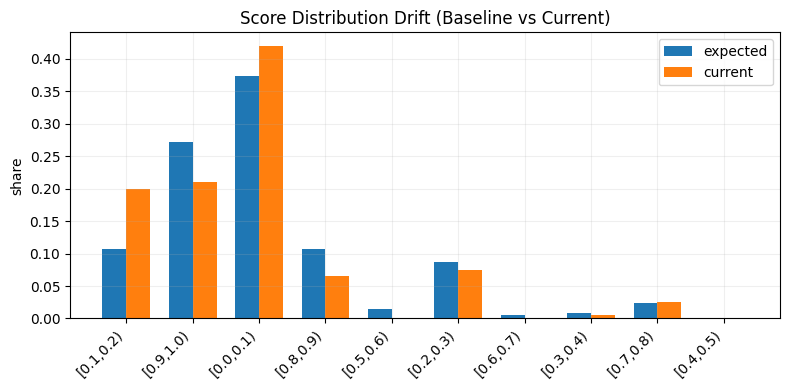

In [4]:
# Cell 3: Drift + risk diagnostics with alert matrix
def _safe_ratio(counts: np.ndarray) -> np.ndarray:
    total = float(counts.sum())
    if total <= 0:
        return np.ones_like(counts, dtype=float) / max(len(counts), 1)
    return counts / total


def _psi(expected: np.ndarray, actual: np.ndarray) -> float:
    eps = 1e-9
    expected = np.clip(expected, eps, None)
    actual = np.clip(actual, eps, None)
    return float(np.sum((actual - expected) * np.log(actual / expected)))


def _js_divergence(expected: np.ndarray, actual: np.ndarray) -> float:
    eps = 1e-9
    p = np.clip(expected, eps, None)
    q = np.clip(actual, eps, None)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return float(0.5 * (kl_pm + kl_qm))


if not scored.empty and "reorder_probability_30d" in scored.columns:
    scores = pd.to_numeric(scored["reorder_probability_30d"], errors="coerce").dropna().to_numpy()
else:
    scores = np.array([], dtype=float)

bin_edges = np.array(baseline.get("bin_edges", []), dtype=float)
expected_dist = np.array(baseline.get("test_distribution", []), dtype=float)

psi_value = np.nan
js_value = np.nan
current_dist = np.array([])
drift_table = pd.DataFrame()

if len(scores) > 0 and len(bin_edges) >= 2 and len(expected_dist) == len(bin_edges) - 1:
    counts, _ = np.histogram(scores, bins=bin_edges)
    current_dist = _safe_ratio(counts)
    psi_value = _psi(expected_dist, current_dist)
    js_value = _js_divergence(expected_dist, current_dist)

    drift_table = pd.DataFrame(
        {
            "bin_left": bin_edges[:-1],
            "bin_right": bin_edges[1:],
            "expected_dist": expected_dist,
            "current_dist": current_dist,
        }
    )
    drift_table["delta"] = drift_table["current_dist"] - drift_table["expected_dist"]
    drift_table["abs_delta"] = drift_table["delta"].abs()
    drift_table = drift_table.sort_values("abs_delta", ascending=False).reset_index(drop=True)

risk_share = scored["risk_bucket"].value_counts(normalize=True).to_dict() if (not scored.empty and "risk_bucket" in scored.columns) else {}
high_rate = float(risk_share.get("high", 0.0))
med_rate = float(risk_share.get("medium", 0.0))
low_rate = float(risk_share.get("low", 0.0))

if not scored.empty and "threshold_band" in scored.columns:
    near_threshold_rate = float((scored["threshold_band"] == "near_threshold").mean())
else:
    near_threshold_rate = np.nan

recommended_threshold = _safe_float(metrics.get("threshold"))
baseline_mean_score = _safe_float(baseline.get("test_mean_score"))
baseline_std_score = _safe_float(baseline.get("test_std_score"))
baseline_pred_pos_rate = _safe_float(metrics.get("test_metrics", {}).get("predicted_positive_rate"))

# Estimate baseline risk mix directly from baseline score bins.
baseline_high_risk_rate = np.nan
baseline_low_risk_rate = np.nan
if len(expected_dist) == len(bin_edges) - 1:
    baseline_high_risk_rate = float(expected_dist[bin_edges[:-1] < 0.3].sum())
    baseline_low_risk_rate = float(expected_dist[bin_edges[:-1] >= 0.6].sum())

if len(scores) > 0 and pd.notna(recommended_threshold):
    live_pred_pos_rate = float((scores >= recommended_threshold).mean())
else:
    live_pred_pos_rate = np.nan
pred_pos_rate_delta = (
    live_pred_pos_rate - baseline_pred_pos_rate
    if pd.notna(live_pred_pos_rate) and pd.notna(baseline_pred_pos_rate)
    else np.nan
)

score_mean = float(np.mean(scores)) if len(scores) else np.nan
score_std = float(np.std(scores)) if len(scores) else np.nan

# Sample-aware drift thresholds and dual-signal (PSI + JS) drift alerting.
scored_users = int(len(scores))
if scored_users >= 500:
    psi_alert_threshold = 0.25
    psi_warn_threshold = 0.15
elif scored_users >= 200:
    psi_alert_threshold = 0.40
    psi_warn_threshold = 0.25
else:
    psi_alert_threshold = 0.50
    psi_warn_threshold = 0.30

js_alert_threshold = 0.03
js_warn_threshold = 0.02
psi_alert = bool(
    pd.notna(psi_value)
    and psi_value >= psi_alert_threshold
    and (pd.isna(js_value) or js_value >= js_alert_threshold)
)
psi_warn = bool(
    pd.notna(psi_value)
    and not psi_alert
    and psi_value >= psi_warn_threshold
    and (pd.isna(js_value) or js_value >= js_warn_threshold)
)

# Baseline-relative risk-mix guardrails.
if pd.notna(baseline_high_risk_rate):
    high_risk_warn_threshold = max(0.35, min(0.85, baseline_high_risk_rate + 0.15))
    high_risk_alert_threshold = max(0.45, min(0.90, baseline_high_risk_rate + 0.25))
else:
    high_risk_warn_threshold = 0.35
    high_risk_alert_threshold = 0.45

if pd.notna(baseline_low_risk_rate):
    low_risk_alert_threshold = max(0.05, baseline_low_risk_rate * 0.25)
else:
    low_risk_alert_threshold = 0.10

monitor = {
    "generated_at_utc": datetime.now(UTC).isoformat(),
    "model_version": metrics.get("model_version", baseline.get("model_version")),
    "scored_users": int(len(scored)),
    "psi": None if pd.isna(psi_value) else float(psi_value),
    "js_divergence": None if pd.isna(js_value) else float(js_value),
    "current_mean_score": None if pd.isna(score_mean) else float(score_mean),
    "current_std_score": None if pd.isna(score_std) else float(score_std),
    "baseline_mean_score": None if pd.isna(baseline_mean_score) else float(baseline_mean_score),
    "baseline_std_score": None if pd.isna(baseline_std_score) else float(baseline_std_score),
    "recommended_threshold": None if pd.isna(recommended_threshold) else float(recommended_threshold),
    "risk_mix": {
        "high": high_rate,
        "medium": med_rate,
        "low": low_rate,
    },
    "baseline_risk_mix_estimate": {
        "high": None if pd.isna(baseline_high_risk_rate) else float(baseline_high_risk_rate),
        "low": None if pd.isna(baseline_low_risk_rate) else float(baseline_low_risk_rate),
    },
    "near_threshold_rate": None if pd.isna(near_threshold_rate) else float(near_threshold_rate),
    "predicted_positive_rate_live": None if pd.isna(live_pred_pos_rate) else float(live_pred_pos_rate),
    "predicted_positive_rate_test": None if pd.isna(baseline_pred_pos_rate) else float(baseline_pred_pos_rate),
    "predicted_positive_rate_delta": None if pd.isna(pred_pos_rate_delta) else float(pred_pos_rate_delta),
    "alerts": {
        "psi_alert": psi_alert,
        "psi_warn": psi_warn,
        "high_risk_alert": bool(high_rate >= high_risk_alert_threshold),
        "high_risk_warn": bool(high_risk_warn_threshold <= high_rate < high_risk_alert_threshold),
        "low_risk_collapse_alert": bool(low_rate <= low_risk_alert_threshold),
        "predicted_positive_shift_alert": bool(pd.notna(pred_pos_rate_delta) and abs(pred_pos_rate_delta) >= 0.15),
        "missing_score_data_alert": bool(len(scores) == 0),
    },
    "thresholds": {
        "psi_alert_threshold": psi_alert_threshold,
        "psi_warn_threshold": psi_warn_threshold,
        "js_alert_threshold": js_alert_threshold,
        "js_warn_threshold": js_warn_threshold,
        "max_high_risk_rate": high_risk_alert_threshold,
        "warn_high_risk_rate": high_risk_warn_threshold,
        "min_low_risk_rate": low_risk_alert_threshold,
        "max_pred_positive_delta": 0.15,
    },
}

alerts_df = pd.DataFrame(
    [
        {"alert": k, "triggered": v}
        for k, v in monitor["alerts"].items()
    ]
)

print("Monitor snapshot:")
print(json.dumps(monitor, indent=2))
display(alerts_df)

if not drift_table.empty:
    display(drift_table)

if not scored.empty and "score_decile" in scored.columns:
    decile_profile = (
        scored.groupby("score_decile", as_index=False)
        .agg(
            users=("user_id", "size"),
            avg_reorder_prob=("reorder_probability_30d", "mean"),
            avg_churn_prob=("churn_probability_30d", "mean"),
        )
        .sort_values("score_decile")
    )
    display(decile_profile)

if HAS_MPL and not drift_table.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(drift_table))
    ax.bar(x - 0.18, drift_table["expected_dist"], width=0.36, label="expected")
    ax.bar(x + 0.18, drift_table["current_dist"], width=0.36, label="current")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"[{l:.1f},{r:.1f})" for l, r in zip(drift_table["bin_left"], drift_table["bin_right"])],
        rotation=45,
        ha="right",
    )
    ax.set_title("Score Distribution Drift (Baseline vs Current)")
    ax.set_ylabel("share")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## Release Decision

Decision policy:

- **`block`** if any critical failures or critical monitoring alerts are present.
- **`pilot`** if there are no critical failures but there are warnings.
- **`ship`** only when checks are clean and alerts are quiet.

In [5]:
# Cell 4: Decision engine + remediation plan
fail_checks = checks_df[checks_df["status"] == "fail"].copy()
warn_checks = checks_df[checks_df["status"] == "warn"].copy()

reason_codes: list[str] = [f"FAIL_{c.upper()}" for c in fail_checks["check"].tolist()]
warning_codes: list[str] = [f"WARN_{c.upper()}" for c in warn_checks["check"].tolist()]

if monitor["alerts"]["psi_alert"]:
    reason_codes.append("FAIL_PSI_ALERT")
elif monitor["alerts"]["psi_warn"]:
    warning_codes.append("WARN_PSI_ELEVATED")

if monitor["alerts"]["high_risk_alert"]:
    reason_codes.append("FAIL_HIGH_RISK_ALERT")
elif monitor["alerts"]["high_risk_warn"]:
    warning_codes.append("WARN_HIGH_RISK_ELEVATED")

if monitor["alerts"]["low_risk_collapse_alert"]:
    reason_codes.append("FAIL_LOW_RISK_COLLAPSE")

if monitor["alerts"]["predicted_positive_shift_alert"]:
    reason_codes.append("FAIL_PRED_POSITIVE_RATE_SHIFT")

if monitor["alerts"]["missing_score_data_alert"]:
    reason_codes.append("FAIL_MISSING_SCORE_DATA")

reason_codes = sorted(set(reason_codes))
warning_codes = sorted(set([code for code in warning_codes if code.replace("WARN_", "FAIL_") not in reason_codes]))

if reason_codes:
    final_decision = "block"
elif warning_codes:
    final_decision = "pilot"
else:
    final_decision = "ship"

release_blocked = final_decision == "block"

pass_count = int((checks_df["status"] == "pass").sum())
warn_count = int((checks_df["status"] == "warn").sum())
fail_count = int((checks_df["status"] == "fail").sum())
total_checks = int(len(checks_df))
readiness_score = float((pass_count + 0.5 * warn_count) / max(total_checks, 1))

study_checks = checks_df[checks_df["chapter"].notna()].copy()
study_total = int(len(study_checks))
study_pass = int((study_checks["status"] == "pass").sum())
study_warn = int((study_checks["status"] == "warn").sum())
study_score = float((study_pass + 0.5 * study_warn) / max(study_total, 1))

action_plan: list[str] = []
if "FAIL_PSI_ALERT" in reason_codes:
    action_plan.append("Investigate distribution shift by top PSI bins; refresh data extract assumptions and retrain/recalibrate if shift persists.")
if "FAIL_HIGH_RISK_ALERT" in reason_codes:
    action_plan.append("Run targeted diagnostics on high-risk users (feature drift, pipeline freshness, and risk bucket logic) before re-enabling broad rollout.")
if "FAIL_PRED_POSITIVE_RATE_SHIFT" in reason_codes:
    action_plan.append("Re-evaluate the decision threshold against current operating conditions and compare expected vs live precision/recall trade-offs.")
if "FAIL_MISSING_SCORE_DATA" in reason_codes:
    action_plan.append("Re-run notebook 06 deployment scoring to regenerate production scoring outputs.")
if not action_plan and final_decision == "pilot":
    action_plan.append("Proceed with constrained rollout and intensified daily monitoring until warnings clear.")
if not action_plan and final_decision == "ship":
    action_plan.append("Proceed with standard rollout and weekly monitoring cadence.")

release_report = {
    "generated_at_utc": datetime.now(UTC).isoformat(),
    "final_decision": final_decision,
    "release_blocked": release_blocked,
    "readiness_score": readiness_score,
    "study_guide_score": study_score,
    "reason_codes": reason_codes,
    "warning_codes": warning_codes,
    "check_counts": {
        "pass": pass_count,
        "warn": warn_count,
        "fail": fail_count,
        "total": total_checks,
    },
    "checks": checks_df.drop(columns=["status_rank"], errors="ignore").to_dict(orient="records"),
    "monitor_snapshot": monitor,
    "context": {
        "model_version": metrics.get("model_version", baseline.get("model_version")),
        "causal_release_decision": causal_decision.get("final_decision"),
        "cohort_daily_anomalies": cohort_summary.get("daily_anomalies"),
        "deployment_scored_users": deploy_summary.get("scored_users", len(scored)),
    },
    "action_plan": action_plan,
}

decision_card = pd.DataFrame(
    [
        {
            "final_decision": final_decision,
            "release_blocked": release_blocked,
            "readiness_score": round(readiness_score, 4),
            "study_guide_score": round(study_score, 4),
            "fail_checks": fail_count,
            "warn_checks": warn_count,
            "reason_codes": ", ".join(reason_codes) if reason_codes else "NONE",
            "warning_codes": ", ".join(warning_codes) if warning_codes else "NONE",
        }
    ]
)

display(decision_card)
if not fail_checks.empty:
    display(fail_checks)
if not warn_checks.empty:
    display(warn_checks)

,final_decision,release_blocked,readiness_score,study_guide_score,fail_checks,warn_checks,reason_codes,warning_codes
0,ship,False,1.0,1.0,0,0,NONE,NONE


In [6]:
# Cell 5: Persist release + monitoring + study-guide audit outputs
for key in [
    "RELEASE_JSON_PATH",
    "RELEASE_MD_PATH",
    "MONITOR_JSON_PATH",
    "MONITOR_MD_PATH",
    "STUDY_AUDIT_JSON_PATH",
    "STUDY_AUDIT_MD_PATH",
    "CHECKS_CSV_PATH",
]:
    PATHS[key].parent.mkdir(parents=True, exist_ok=True)

PATHS["RELEASE_JSON_PATH"].write_text(json.dumps(release_report, indent=2), encoding="utf-8")
PATHS["MONITOR_JSON_PATH"].write_text(json.dumps(monitor, indent=2), encoding="utf-8")
checks_df.drop(columns=["status_rank"], errors="ignore").to_csv(PATHS["CHECKS_CSV_PATH"], index=False)

release_md_lines = [
    "# SliceIQ Production Readiness Report",
    "",
    f"- Generated at (UTC): {release_report['generated_at_utc']}",
    f"- Final decision: {release_report['final_decision']}",
    f"- Release blocked: {release_report['release_blocked']}",
    f"- Readiness score: {release_report['readiness_score']:.4f}",
    f"- Study guide score: {release_report['study_guide_score']:.4f}",
    f"- Reason codes: {', '.join(release_report['reason_codes']) if release_report['reason_codes'] else 'NONE'}",
    f"- Warning codes: {', '.join(release_report['warning_codes']) if release_report['warning_codes'] else 'NONE'}",
    "",
    "## Monitoring Snapshot",
    f"- PSI: {monitor['psi']}",
    f"- JS divergence: {monitor['js_divergence']}",
    f"- High risk share: {monitor['risk_mix']['high']:.4f}",
    f"- Medium risk share: {monitor['risk_mix']['medium']:.4f}",
    f"- Low risk share: {monitor['risk_mix']['low']:.4f}",
    f"- Predicted-positive delta (live - test): {monitor['predicted_positive_rate_delta']}",
    "",
    "## Context from Prior Notebooks",
    f"- Notebook 04 causal decision: {release_report['context']['causal_release_decision']}",
    f"- Notebook 05 daily anomalies: {release_report['context']['cohort_daily_anomalies']}",
    f"- Notebook 06 scored users: {release_report['context']['deployment_scored_users']}",
    "",
    "## Action Plan",
]
for step in release_report["action_plan"]:
    release_md_lines.append(f"- {step}")
PATHS["RELEASE_MD_PATH"].write_text("\n".join(release_md_lines), encoding="utf-8")

monitor_md_lines = [
    "# SliceIQ Production Monitoring Snapshot",
    "",
    f"- Generated at (UTC): {monitor['generated_at_utc']}",
    f"- Scored users: {monitor['scored_users']}",
    f"- PSI: {monitor['psi']}",
    f"- JS divergence: {monitor['js_divergence']}",
    f"- Mean score: {monitor['current_mean_score']}",
    f"- Baseline mean score: {monitor['baseline_mean_score']}",
    f"- Risk mix (H/M/L): {monitor['risk_mix']['high']:.4f} / {monitor['risk_mix']['medium']:.4f} / {monitor['risk_mix']['low']:.4f}",
    f"- Alerts: {monitor['alerts']}",
]
PATHS["MONITOR_MD_PATH"].write_text("\n".join(monitor_md_lines), encoding="utf-8")

study_df = checks_df[checks_df["chapter"].notna()].drop(columns=["status_rank"], errors="ignore").copy()
chapter_summary_df = (
    study_df.groupby(["chapter", "status"]).size().unstack(fill_value=0)
    if not study_df.empty
    else pd.DataFrame()
)
study_payload = {
    "generated_at_utc": datetime.now(UTC).isoformat(),
    "summary": study_df["status"].value_counts().to_dict() if not study_df.empty else {},
    "by_chapter": chapter_summary_df.to_dict(orient="index") if not chapter_summary_df.empty else {},
    "rows": study_df.to_dict(orient="records"),
}
PATHS["STUDY_AUDIT_JSON_PATH"].write_text(json.dumps(study_payload, indent=2), encoding="utf-8")

study_md_lines = [
    "# SliceIQ Study Guide Implementation Audit",
    "",
    f"- Generated at (UTC): {study_payload['generated_at_utc']}",
    f"- Pass: {study_payload['summary'].get('pass', 0)}",
    f"- Warn: {study_payload['summary'].get('warn', 0)}",
    f"- Fail: {study_payload['summary'].get('fail', 0)}",
    "",
    "## Detailed Checks",
]
for row in study_payload["rows"]:
    study_md_lines.append(
        f"- [{row['status'].upper()}] {row['chapter']} :: {row['check']} :: value={row['value']} :: threshold={row['threshold']}"
    )
PATHS["STUDY_AUDIT_MD_PATH"].write_text("\n".join(study_md_lines), encoding="utf-8")

output_rows = [
    {"artifact": "release_json", "path": str(PATHS["RELEASE_JSON_PATH"]), "exists": PATHS["RELEASE_JSON_PATH"].exists()},
    {"artifact": "release_md", "path": str(PATHS["RELEASE_MD_PATH"]), "exists": PATHS["RELEASE_MD_PATH"].exists()},
    {"artifact": "monitor_json", "path": str(PATHS["MONITOR_JSON_PATH"]), "exists": PATHS["MONITOR_JSON_PATH"].exists()},
    {"artifact": "monitor_md", "path": str(PATHS["MONITOR_MD_PATH"]), "exists": PATHS["MONITOR_MD_PATH"].exists()},
    {"artifact": "study_audit_json", "path": str(PATHS["STUDY_AUDIT_JSON_PATH"]), "exists": PATHS["STUDY_AUDIT_JSON_PATH"].exists()},
    {"artifact": "study_audit_md", "path": str(PATHS["STUDY_AUDIT_MD_PATH"]), "exists": PATHS["STUDY_AUDIT_MD_PATH"].exists()},
    {"artifact": "checks_csv", "path": str(PATHS["CHECKS_CSV_PATH"]), "exists": PATHS["CHECKS_CSV_PATH"].exists()},
]
display(pd.DataFrame(output_rows))
print("Release decision:", release_report["final_decision"], "| blocked:", release_report["release_blocked"])

,artifact,path,exists
0,release_json,/Users/deliorincon/Desktop/Sliceiq/ml/models/r...,True
1,release_md,/Users/deliorincon/Desktop/Sliceiq/ml/models/r...,True
2,monitor_json,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,True
3,monitor_md,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,True
4,study_audit_json,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,True
5,study_audit_md,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,True
6,checks_csv,/Users/deliorincon/Desktop/Sliceiq/ml/data/rep...,True


Release decision: ship | blocked: False


## Next Notebook

Proceed to `08_causal_production_decisioning.ipynb` once this gate is `ship` (or intentionally run as `pilot` under explicit stakeholder approval).